# Stock Price Prediction using ARIMA

This project explores time-series forecasting of stock prices using the ARIMA model. Our current checkpoint focuses on building a baseline ARIMA model using Apple stock price data.

**Team Members:**
- **Shivani Kankatala** [ShivaniKankatala]
- **Poorvi Nidsoshi** [poorvinidsoshi01]
- **Priyanka Pawar** [ppawar03-byte]


## Overview

**What are we trying to do?**

We are trying to build a model that can predict future stock prices using historical market data. Specifically, we aim to forecast short‑term price movements of major technology stocks using time‑series models.

**What is new in our approach?**

Our approach combines classical time‑series modeling (ARIMA) with feature engineering such as technical indicators (moving averages, RSI, MACD) generated in our preprocessing pipeline. The ARIMA model currently serves as our baseline model.

**Who cares?**

Investors, financial analysts, and trading platforms can benefit from predictive models that estimate short‑term price movements. Our primary stakeholder is individual investors who want data‑driven insights for decision making.

## Data

**Data Source**

The dataset contains historical stock price data including Open, High, Low, Close, Adjusted Close, and Volume values.

Example source:
- Yahoo Finance historical data
- https://finance.yahoo.com/

This dataset is considered credible because it originates from a widely used financial data provider used by researchers and financial institutions.

**Dataset Features**

- Date
- Open
- High
- Low
- Close
- Adjusted Close
- Volume

We focus primarily on the **Close price** for time‑series forecasting.

## Exploratory Data Analysis

We explored the distribution of stock prices over time to identify patterns and volatility. The following plot shows how Apple stock prices change over time.

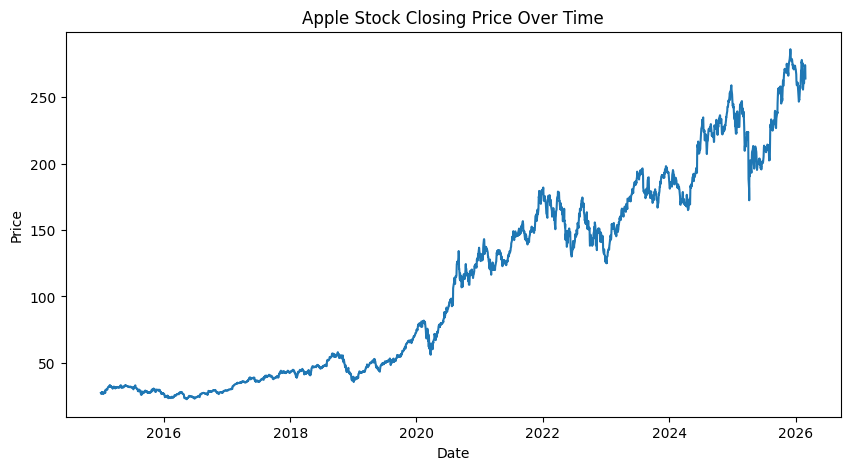

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Apple.csv')

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title('Apple Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

The visualization shows that stock prices fluctuate significantly over time, confirming that this is a non‑stationary time series suitable for ARIMA modeling.

## Preprocessing

Before modeling, the dataset required several preprocessing steps:

1. Converted the **Date column** into a datetime format.
2. Set the **Date column as the index** for time‑series analysis.
3. Selected the **Close price** as the primary variable for prediction.
4. Split the dataset into training and testing sets.

Training data includes observations before 2024, while testing data includes observations from 2024 onward.

In [3]:
series = df['Close']

train = series[series.index < '2024-01-01']
test = series[series.index >= '2024-01-01']

print(len(train), len(test))

2264 541


## Modeling

We implemented an **ARIMA(5,1,0)** model as our baseline forecasting model. ARIMA is widely used for time‑series forecasting because it captures autoregressive and trend components.

The model was trained on historical data and used to predict future stock prices.

In [4]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2264
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -4568.035
Date:                Fri, 06 Mar 2026   AIC                           9148.071
Time:                        22:51:44   BIC                           9182.417
Sample:                             0   HQIC                          9160.603
                               - 2264                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0374      0.013     -2.936      0.003      -0.062      -0.012
ar.L2         -0.0240      0.013     -1.779      0.075      -0.050       0.002
ar.L3         -0.0130      0.014     -0.924      0.3

/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecas

### Model Evaluation

We evaluated the model using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Results from the Apple dataset:

- **MAE:** 35.25
- **RMSE:** 42.66


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predictions = model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 195.55897462759486
RMSE: 197.85130489914675


/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Visualization of Predictions

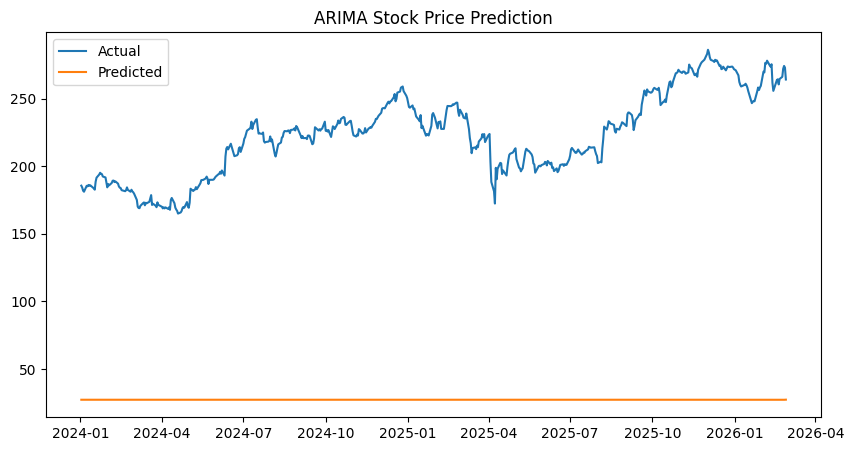

In [6]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Predicted')

plt.title('ARIMA Stock Price Prediction')
plt.legend()
plt.show()

### Future Forecast

The ARIMA model was also used to predict the next 7 days of stock prices.

In [7]:
future = model_fit.forecast(steps=7)
print('Next 7 Day Predictions')
print(future)

Next 7 Day Predictions
2264    27.308443
2265    27.252275
2266    27.230624
2267    27.230141
2268    27.261275
2269    27.259753
2270    27.256967
Name: predicted_mean, dtype: float64


/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Problems & Challenges

Several challenges were encountered during the modeling process:

- Some warnings appeared during ARIMA training related to covariance estimation.
- Stock prices are highly volatile and difficult to predict using simple models.
- Selecting optimal ARIMA parameters requires further tuning.

These challenges will be addressed by experimenting with additional models and feature engineering.

## Next Steps

Our next steps include:

1. Train ARIMA models for other stocks (Microsoft, Amazon, NVIDIA, Google).
2. Compare performance across multiple models.
3. Implement machine learning models such as Random Forest and LSTM.
4. Tune ARIMA hyperparameters using grid search.
5. Combine technical indicators with predictive models.

**Estimated timeline:**

- ARIMA models for all stocks: Week 1
- ML models implementation: Week 2
- Model comparison and final evaluation: Week 3
